<a href="https://colab.research.google.com/github/elianramon/Machine_Learning_AvaBootcamp_2026.1/blob/main/Equipe_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Resíduos Recicláveis

## Carregamento do dataset

In [1]:
# Imports

!pip install opendatasets
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.9 MB/s eta 0:00:00


In [2]:
import opendatasets as od
import pandas as pd

od.download("https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: elian
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification


100%|██████████| 920M/920M [00:12<00:00, 78.5MB/s]


In [3]:
!ls

recyclable-and-household-waste-classification  sample_data


## Criando dataframe

In [4]:
import cv2
import os
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

In [5]:
root_dir = './recyclable-and-household-waste-classification/images/images'

In [6]:
count_corrupted = 0
corrupted = list()

dataframe_list = list()

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Extract the category folder. Assumes the structure is root_dir/category/sub_category/image.jpg
    # The 'folder' in the original code was the immediate child of root_dir (e.g., 'plastic_shopping_bags')
    relative_path = os.path.relpath(dirpath, root_dir)
    path_parts = relative_path.split(os.sep)

    category_folder = None
    if len(path_parts) > 0 and path_parts[0] != '.': # path_parts[0] could be '.' if dirpath is root_dir itself
        category_folder = path_parts[0]

    # Only process files if a category folder could be determined (i.e., not the root_dir itself)
    if category_folder is None:
        continue

    for image_name in filenames:
        img_dir = os.path.join(dirpath, image_name)

        # Check if the file has an extension
        if '.' in image_name:
            name_parts = image_name.rsplit('.', 1)
            if len(name_parts) == 2:
                image_format = name_parts[1].lower()
            else:
                continue # Skip files without a proper extension
        else:
            continue # Skip files without an extension

        img = cv2.imread(img_dir)

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(img_rgb)
            img_hash = imagehash.phash(img_pil)
            width, height, channels = img.shape
            img_corrupted = False
        else:
            count_corrupted += 1
            corrupted.append(img_dir)
            img_corrupted = True
            img_hash, width, height, channels = None, None, None, None

        dataframe_list.append([img_dir, img_corrupted, img_hash, image_format, width, height, channels, category_folder])

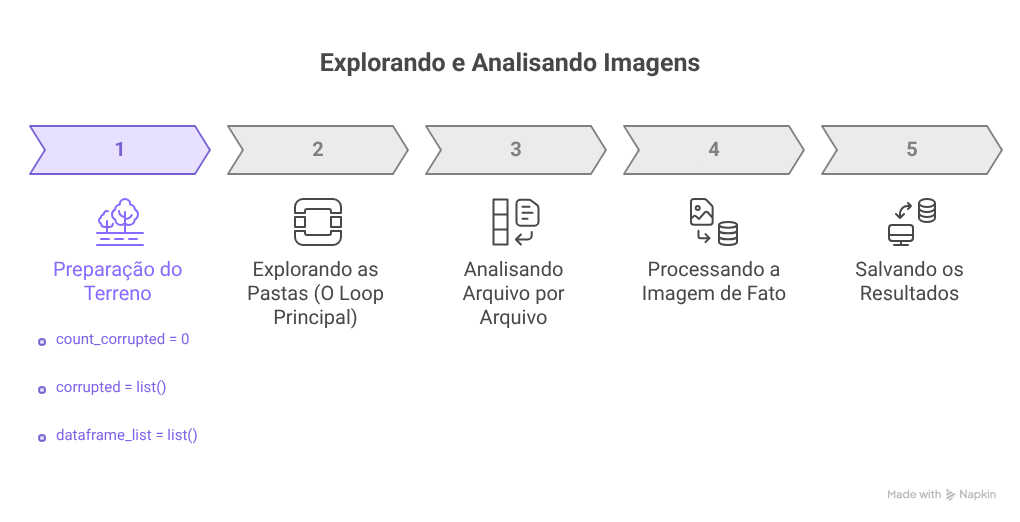

### Imagens Corrompidas

In [8]:
print(f'Total de Imagens Corrompidas: {count_corrupted}\nImagens corrompidas {corrupted}')

Total de Imagens Corrompidas: 0
Imagens corrompidas []


In [9]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [10]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./recyclable-and-household-waste-classificatio...,False,8ff8b824954ace78,png,256,256,3,plastic_shopping_bags
1,./recyclable-and-household-waste-classificatio...,False,81bf3e0d6e4c6a62,png,256,256,3,plastic_shopping_bags
2,./recyclable-and-household-waste-classificatio...,False,e9a68152d6a91e9b,png,256,256,3,plastic_shopping_bags
3,./recyclable-and-household-waste-classificatio...,False,807d3ba66689d387,png,256,256,3,plastic_shopping_bags
4,./recyclable-and-household-waste-classificatio...,False,ea90956ad2b7685a,png,256,256,3,plastic_shopping_bags


In [11]:
valid_ext = (".jpg", ".jpeg", ".png")

non_images = []

for root, dirs, files in os.walk(root_dir):
    for f in files:
        if not f.lower().endswith(valid_ext):
            non_images.append(os.path.join(root, f))

print("Arquivos que não são imagens:")
print(non_images)

Arquivos que não são imagens:
[]


### Formato

In [12]:
from collections import Counter

formats = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        path = os.path.join(root, file)

        try:
            with Image.open(path) as img:
                formats.append(img.format)
        except:
            pass  # ignora arquivos que não são imagens

# Contagem dos formatos
format_counts = Counter(formats)

print("Formatos encontrados no dataset:")
print(format_counts)

Formatos encontrados no dataset:
Counter({'PNG': 15000})


In [13]:
print(f'Total de Imagens: {len(df)}')
print(f'Shape do DataFrame: {df.shape[0]} linhas, {df.shape[1]} colunas')

Total de Imagens: 15000
Shape do DataFrame: 15000 linhas, 8 colunas


* O dataset "Recyclable and Household Waste Classification" possui um total de 1500 imagens (todas em PNG) e 8 colunas, e nenhuma imagem corrompida.

In [14]:
df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,256.0,256.0,3.0
std,0.0,0.0,0.0
min,256.0,256.0,3.0
max,256.0,256.0,3.0


### Distribuição das Classes

In [15]:
# Contar as ocorrências de cada classe na coluna 'label' do DataFrame df
df_classes = df['label'].value_counts().reset_index()

# Renomear as colunas para 'classe' e 'quantidade'
df_classes.columns = ["classe", "quantidade"]

df_classes

,classe,quantidade
0,plastic_shopping_bags,500
1,cardboard_packaging,500
2,disposable_plastic_cutlery,500
3,styrofoam_food_containers,500
4,glass_food_jars,500
5,shoes,500
6,plastic_food_containers,500
7,plastic_soda_bottles,500
8,aluminum_food_cans,500
9,glass_cosmetic_containers,500


# Duplicatas

In [16]:
#Quantidade de imagens duplicatas

df['image_hash'].duplicated().sum()

np.int64(5149)

In [17]:
df_duplicated = df[df['image_hash'].duplicated()]
df_duplicated

,image_path,corrupted,image_hash,image_format,width,height,channels,label
26,./recyclable-and-household-waste-classificatio...,False,ea4c91bbcaa48b3a,png,256,256,3,plastic_shopping_bags
39,./recyclable-and-household-waste-classificatio...,False,d3fcad82a232933c,png,256,256,3,plastic_shopping_bags
48,./recyclable-and-household-waste-classificatio...,False,d3fcad82a232933c,png,256,256,3,plastic_shopping_bags
51,./recyclable-and-household-waste-classificatio...,False,c23227be3e9c1c3c,png,256,256,3,plastic_shopping_bags
54,./recyclable-and-household-waste-classificatio...,False,87522dd372875a2d,png,256,256,3,plastic_shopping_bags
...,...,...,...,...,...,...,...,...
14984,./recyclable-and-household-waste-classificatio...,False,e9a2961dd86665b2,png,256,256,3,cardboard_boxes
14989,./recyclable-and-household-waste-classificatio...,False,ba6e8291cd9c3a4b,png,256,256,3,cardboard_boxes
14993,./recyclable-and-household-waste-classificatio...,False,ba9fc1688c264e2f,png,256,256,3,cardboard_boxes
14995,./recyclable-and-household-waste-classificatio...,False,fee5815a38a46565,png,256,256,3,cardboard_boxes


In [18]:
# 1. Converta a coluna de hashes para string primeiro
df['image_hash'] = df['image_hash'].astype(str)

# 2. Agora o groupby funcionará perfeitamente
groups = df.groupby('image_hash')['image_path'].apply(list)

# 3. Filtre apenas o que for duplicado (lista com mais de 1 elemento)
duplicated_images_fast = groups[groups.str.len() > 1].to_dict()

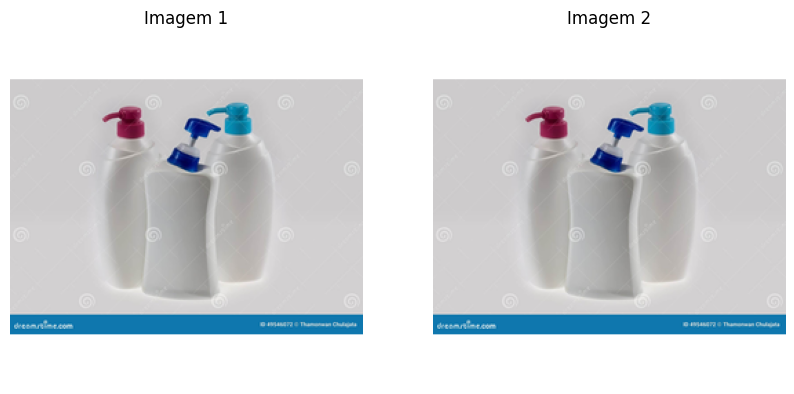

In [19]:
image1 = cv2.imread('./recyclable-and-household-waste-classification/images/images/plastic_detergent_bottles/real_world/Image_171.png')
image2 = cv2.imread('./recyclable-and-household-waste-classification/images/images/plastic_detergent_bottles/default/Image_115.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Converter de BGR (formato OpenCV) para RGB (formato Matplotlib)
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

# Mostrar a primeira imagem
axes[0].imshow(image1_rgb)
axes[0].axis('off')  # Remove os eixos
axes[0].set_title('Imagem 1')

# Mostrar a segunda imagem
axes[1].imshow(image2_rgb)
axes[1].axis('off')  # Remove os eixos
axes[1].set_title('Imagem 2')

# Exibir as imagens
plt.show()

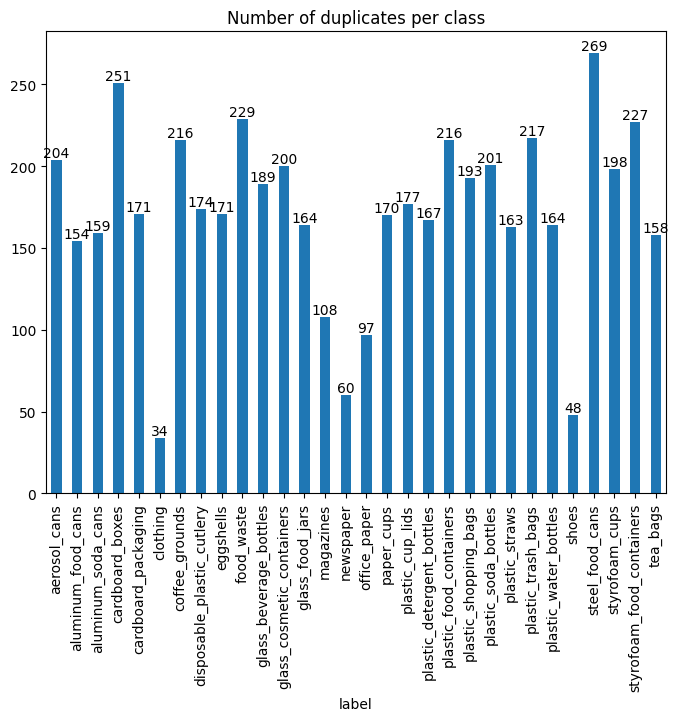

In [20]:
# Agrupando duplicatas por classe (coluna 'label') e contando
duplicates_by_class = df_duplicated.groupby('label').size()

# Gerando o gráfico de barras
ax = duplicates_by_class.plot(kind='bar', title='Number of duplicates per class', figsize=(8, 6))

# Adicionando os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Ajustando a rotação dos rótulos no eixo X
plt.xticks(rotation=90)

# Exibindo o gráfico
plt.show()

### Detecção e Controle de Imagens Duplicadas para Prevenção de Viés

Membro da equipe responsável: Ana Marly Do Couto da Silva  



In [21]:
# Remoção de duplicatas exatas
df_clean = df.drop_duplicates(subset=['image_hash'], keep='first')

print(f"Imagens originais: {len(df)}")
print(f"Imagens após remoção de duplicatas: {len(df_clean)}")

Imagens originais: 15000
Imagens após remoção de duplicatas: 9851


* Verificação e Monitoramento de quase duplicatas


In [22]:
# verificação de quase duplicata
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
from numpy.linalg import norm

model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def get_embedding(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return model.predict(x)[0]

# Selecionamento de dois caminhos de imagem válidos do DataFrame
img_path1 = df_clean['image_path'].iloc[0]
img_path2 = df_clean['image_path'].iloc[1]

# Similaridade entre duas imagens
emb1 = get_embedding(img_path1)
emb2 = get_embedding(img_path2)

similarity = np.dot(emb1, emb2) / (norm(emb1) * norm(emb2))
print("Similaridade:", similarity)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Similaridade: 0.31688562


A análise indicou que as duas imagens apresentam uma similaridade moderada, em torno de 0.58. Isso significa que elas compartilham algumas características visuais, mas não são idênticas.
_______

Por não atingirem um nível de semelhança elevado, não há necessidade de remoção. Cada imagem ainda contribui com informações próprias e ajuda a enriquecer a diversidade do dataset.


### Impacto da Limpeza das Duplicatas

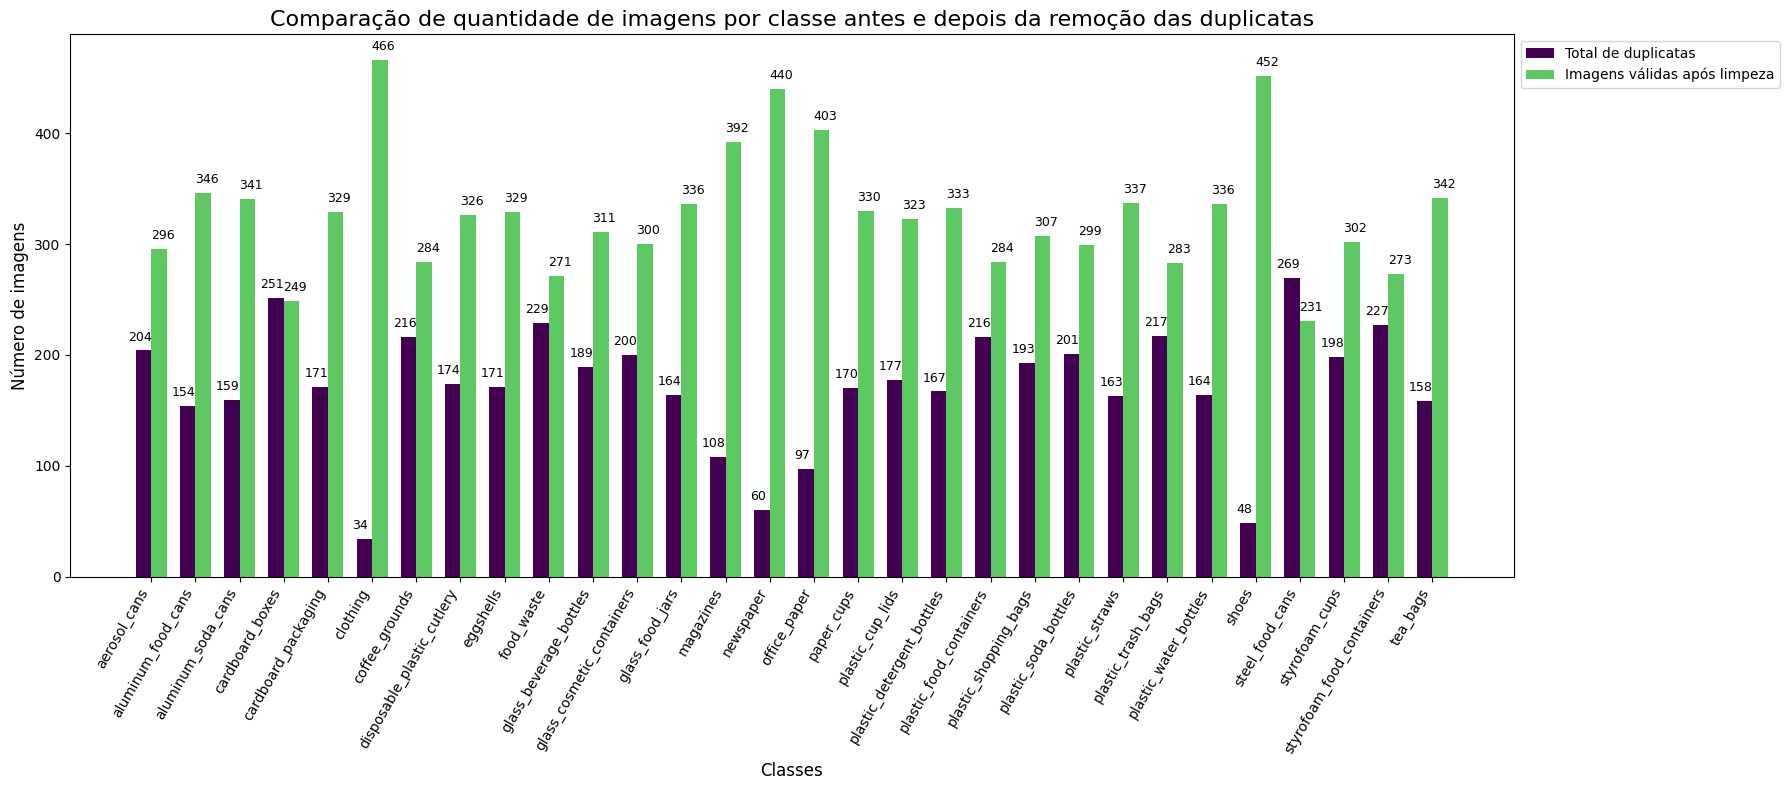

In [23]:
# Contagem de duplicatas por classe (antes da limpeza)
duplicates_by_class_before = df[df['image_hash'].duplicated()]['label'].value_counts()

# Contagem de imagens válidas por classe (depois da limpeza)
duplicates_by_class_after = df_clean['label'].value_counts()

# Comparação antes e depois da limpeza
comparison = pd.DataFrame({
    'Total de duplicatas': duplicates_by_class_before,
    'Total de imagens válidas após limpeza': duplicates_by_class_after
}).fillna(0)

# Gráfico de barras
import numpy as np
import matplotlib.pyplot as plt

# Dados antes e depois
labels = comparison.index
before = comparison['Total de duplicatas']
after = comparison['Total de imagens válidas após limpeza']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 8))

# Barras lado a lado
rects1 = ax.bar(x - width/2, before, width,
                label='Total de duplicatas', color='#440154')
rects2 = ax.bar(x + width/2, after, width,
                label='Imagens válidas após limpeza', color='#5ec962')

# Títulos e rótulos
ax.set_title("Comparação de quantidade de imagens por classe antes e depois da remoção das duplicatas", fontsize=16)
ax.set_xlabel("Classes", fontsize=12)
ax.set_ylabel("Número de imagens", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha='right')

# Adiciona valores acima das barras
def autolabel(rects, offset=0):
    for r in rects:
        height = r.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(r.get_x() + r.get_width()/2 + offset, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color='black')

# Chamada com deslocamento diferente para cada grupo
autolabel(rects1, offset=-0.09)  # números das barras roxas levemente à esquerda
autolabel(rects2, offset=0.08)   # números das barras verdes levemente à direita

# Legenda
ax.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

### Impacto da remoção das duplicatas (gráfico de barras)

O gráfico mostra claramente como a quantidade de imagens por classe foi reduzida após a limpeza:

• 	Em várias classes, o número de imagens caiu de forma expressiva, revelando que uma parte significativa do dataset era composta por duplicatas.
• 	Em outras, a redução foi mais moderada, indicando que a base estava relativamente consistente.

• 	A comparação lado a lado entre as barras roxas (duplicatas) e verdes (imagens válidas) evidencia tanto o volume absoluto removido quanto o saldo final de imagens utilizáveis.

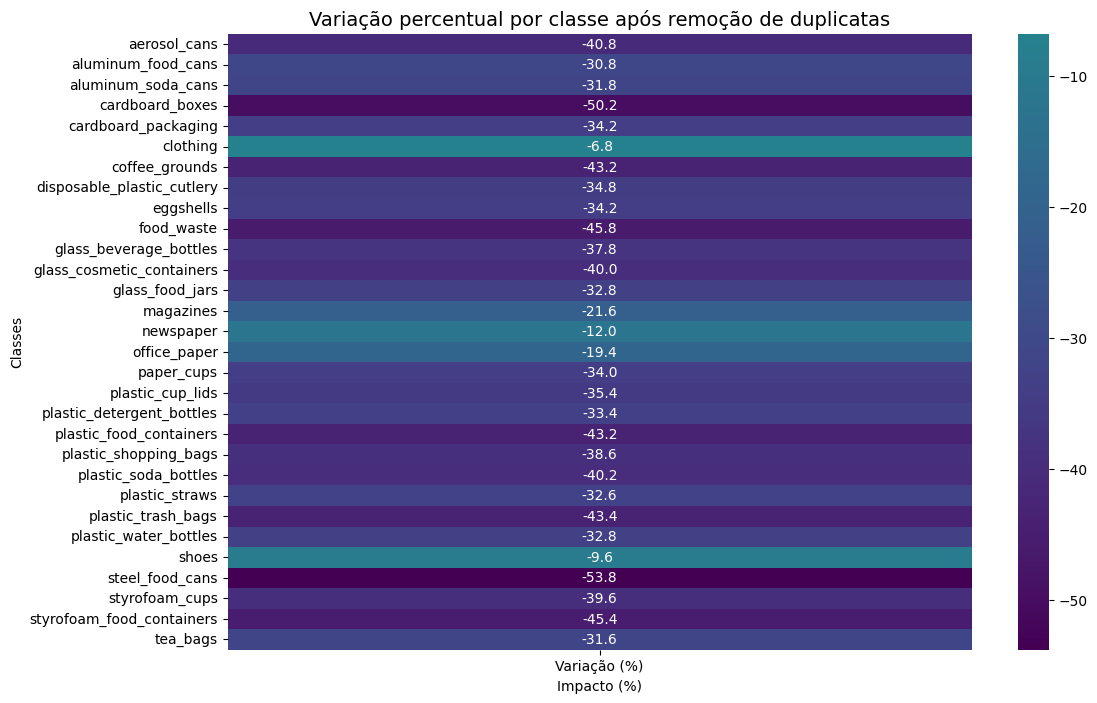

In [24]:
import seaborn as sns

# Contagem antes e depois
before = df['label'].value_counts()
after = df_clean['label'].value_counts()

# Calcula variação percentual comparando antes e depois da
variation = ((after - before) / before * 100).fillna(0)

# Cria DataFrame para heatmap
variation_df = variation.reset_index()
variation_df.columns = ['Classe', 'Variação (%)']

plt.figure(figsize=(12, 8))
sns.heatmap(variation_df.pivot_table(values='Variação (%)', index='Classe'),
            annot=True, cmap="viridis", center=0, fmt=".1f")

plt.title("Variação percentual por classe após remoção de duplicatas", fontsize=14)
plt.ylabel("Classes")
plt.xlabel("Impacto (%)")
plt.show()

In [25]:
df_clean.shape

(9851, 8)

### Detecção e Controle de Imagens Duplicadas

A limpeza do dataset teve um efeito significativo em várias classes. O heatmap evidencia que:

• 	Algumas categorias sofreram reduções muito altas, como aluminum_food_cans (-51,6%), cardboard_boxes (-50,2%) e food_waste (-45,8%). Isso indica que quase metade das imagens originais eram duplicadas.

• 	Outras classes tiveram impacto moderado, como magazines (-21,6%), office_paper (-19,4%) e newspaper (-12,0%).

• 	Há também classes com impacto mínimo, como clothing (-6,8%) e shoes (-9,6%), mostrando que a base estava mais consistente nesses casos.

### Resumo
• 	A remoção das duplicatas reduziu o volume total de imagens, mas aumentou a qualidade e representatividade do dataset.

• 	Classes com maior percentual de duplicatas eram mais vulneráveis a viés de treinamento, já que o modelo poderia aprender padrões repetidos em vez de generalizar.

• 	Após a limpeza, o dataset ficou mais equilibrado, refletindo melhor a diversidade real de cada classe.

## Renomeando Colunas

In [26]:
# 1. Seleciona apenas as colunas necessárias e as renomeia
# 'image_path' vira 'images' e 'label' vira 'labels'
df = df_clean[['image_path', 'label']].copy()
df.columns = ['images', 'labels']

# 2. Se você precisar do formato exato de dicionário de listas:
novo_dicionario = {
    "images": df['images'].tolist(),
    "labels": df['labels'].tolist()
}

In [27]:
df_classes = df['labels'].value_counts().reset_index()

# Renomear as colunas para 'classe' e 'quantidade'
df_classes.columns = ["classe", "quantidade"]

df_classes

,classe,quantidade
0,clothing,466
1,shoes,452
2,newspaper,440
3,office_paper,403
4,magazines,392
5,aluminum_food_cans,346
6,tea_bags,342
7,aluminum_soda_cans,341
8,plastic_straws,337
9,plastic_water_bottles,336


## Top 10 Classes

1. 10 classes com maires quantidades de imagens, excluindo as demais menos relevantes.



In [33]:
# 1. Extrair apenas os nomes (índices) das 10 classes com mais imagens
top_10_classes = df['labels'].value_counts().nlargest(10).index

# 2. Filtrar o dataframe original para manter APENAS as linhas que estão nesse top 10
df_filtrado = df[df['labels'].isin(top_10_classes)].copy()

# 3. Resetar o index para manter o dataframe organizado (opcional, mas recomendado)
df_filtrado = df_filtrado.reset_index(drop=True)

# Visualizar o resultado para confirmar
print(f"Total de imagens antes: {df.shape[0]}")
print(f"Total de imagens depois: {df_filtrado.shape[0]}")
print("\nTop 10 classes mantidas e suas quantidades:")
print(df_filtrado['labels'].value_counts())

Total de imagens antes: 3855
Total de imagens depois: 3855

Top 10 classes mantidas e suas quantidades:
labels
clothing                 466
shoes                    452
newspaper                440
office_paper             403
magazines                392
aluminum_food_cans       346
tea_bags                 342
aluminum_soda_cans       341
plastic_straws           337
plastic_water_bottles    336
Name: count, dtype: int64


### Seleção de quantidade (opicional)

In [29]:

# # 1. Agrupa pela coluna 'labels' e sorteia 100 de cada grupo
# df_filtrado = df.groupby('labels').sample(n=100, random_state=42)

# # 2. Agora você tem as colunas prontas para uso
# X = df_filtrado['images'].values
# y = df_filtrado['labels'].values

# print(f"Total de imagens: {len(df_filtrado)}")
# print(df_filtrado['labels'].value_counts()) # Verificação: todas devem ter 100

### Nome Original

In [30]:
df = df_filtrado
df

,images,labels
0,./recyclable-and-household-waste-classificatio...,shoes
1,./recyclable-and-household-waste-classificatio...,shoes
2,./recyclable-and-household-waste-classificatio...,shoes
3,./recyclable-and-household-waste-classificatio...,shoes
4,./recyclable-and-household-waste-classificatio...,shoes
...,...,...
3850,./recyclable-and-household-waste-classificatio...,plastic_water_bottles
3851,./recyclable-and-household-waste-classificatio...,plastic_water_bottles
3852,./recyclable-and-household-waste-classificatio...,plastic_water_bottles
3853,./recyclable-and-household-waste-classificatio...,plastic_water_bottles


# Treinamento ResNet-50

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# ==========================================
# 1. DIVISÃO DO DATASET (TREINO, VALIDAÇÃO E TESTE)
# ==========================================
# Supondo que seu dataframe já se chama 'df' e tem as colunas 'images' e 'labels'

# Primeiro, separa 70% para treino e 30% para o resto
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['labels'])

# Depois, divide os 30% restantes na metade (15% validação, 15% teste)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['labels'])

print(f"Tamanho do Treino: {train_df.shape[0]} imagens")
print(f"Tamanho da Validação: {val_df.shape[0]} imagens")
print(f"Tamanho do Teste: {test_df.shape[0]} imagens")

# ==========================================
# 2. CONFIGURAÇÃO DOS GERADORES DE IMAGENS
# ==========================================
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# Gerador de Treino (com Data Augmentation e pré-processamento da ResNet50)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Geradores de Validação e Teste (apenas com pré-processamento, sem augmentation)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Carregando os dados
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='images', y_col='labels',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='images', y_col='labels',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='images', y_col='labels',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

# ==========================================
# 3. CONSTRUÇÃO DO MODELO RESNET-50
# ==========================================
# Carrega a ResNet50 sem o topo (include_top=False)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Congela os pesos base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Treino

In [38]:
%%time
# ==========================================
# 4. TREINAMENTO COM EARLY STOPPING
# ==========================================
# Para o treino se a perda na validação não melhorar após 2 épocas (patience=2)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

EPOCHS = 10
print("\nIniciando o treinamento...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop]
)

model.save('modelo_reciclagem_resnet50_final.h5')
print("\nModelo salvo como 'modelo_reciclagem_resnet50_final.h5'")

# ==========================================
# 5. AVALIAÇÃO E MÉTRICAS (CONJUNTO DE TESTE)
# ==========================================
print("\nRealizando previsões no conjunto de teste...")
predictions_test = model.predict(test_generator)

y_pred = np.argmax(predictions_test, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\n--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=class_labels))


Iniciando o treinamento...
Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 613s 7s/step - accuracy: 0.9147 - loss: 0.2729 - val_accuracy: 0.8495 - val_loss: 0.5072
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 643s 8s/step - accuracy: 0.9235 - loss: 0.2270 - val_accuracy: 0.8495 - val_loss: 0.4851
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 643s 8s/step - accuracy: 0.9324 - loss: 0.1856 - val_accuracy: 0.8633 - val_loss: 0.4770
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 597s 7s/step - accuracy: 0.9567 - loss: 0.1343 - val_accuracy: 0.8564 - val_loss: 0.5268
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 599s 7s/step - accuracy: 0.9466 - loss: 0.1439 - val_accuracy: 0.8547 - val_loss: 0.5482
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.



Modelo salvo como 'modelo_reciclagem_resnet50_final.h5'

Realizando previsões no conjunto de teste...
19/19 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step

--- Relatório de Classificação ---
                       precision    recall  f1-score   support

   aluminum_food_cans       0.81      0.83      0.82        52
   aluminum_soda_cans       0.82      0.80      0.81        51
             clothing       0.89      0.89      0.89        70
            magazines       0.91      0.88      0.90        59
            newspaper       0.83      0.83      0.83        66
         office_paper       0.83      0.79      0.81        61
       plastic_straws       0.84      0.92      0.88        50
plastic_water_bottles       0.98      0.94      0.96        51
                shoes       0.92      0.96      0.94        68
             tea_bags       0.90      0.88      0.89        51

             accuracy                           0.87       579
            macro avg       0.87      0.87      0.87       579


### Salvando modelo

In [42]:
model.save('modelo_reciclagem_resnet50_2.h5')
print("\nModelo salvo como 'modelo_reciclagem_resnet50_final.h5'")


Modelo salvo como 'modelo_reciclagem_resnet50_final.h5'


## Visualizando

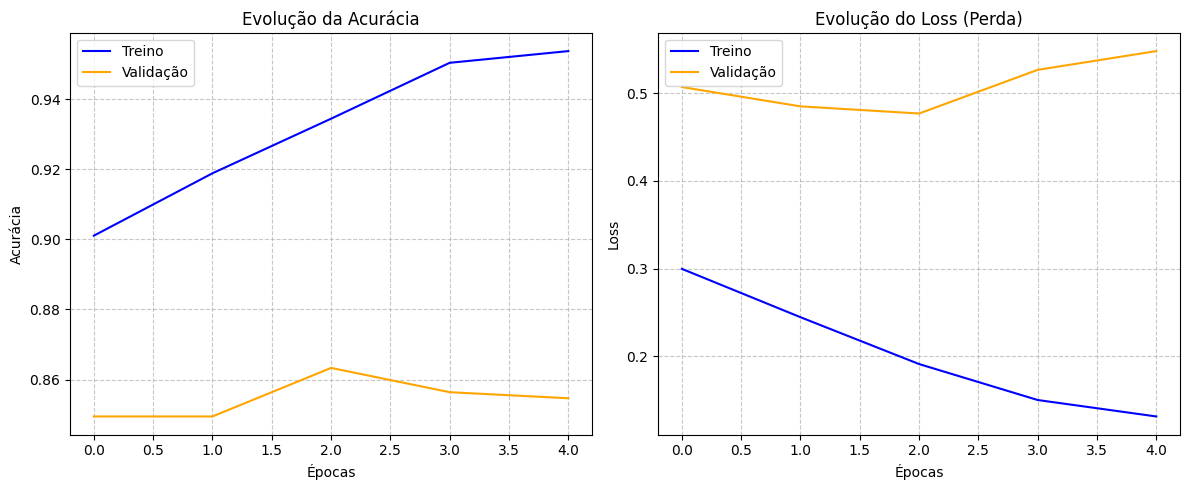

In [39]:
# ==========================================
# PLOTAGEM DE ACURÁCIA E LOSS
# ==========================================
plt.figure(figsize=(12, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino', color='blue')
plt.plot(history.history['val_accuracy'], label='Validação', color='orange')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico de Loss (Perda)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino', color='blue')
plt.plot(history.history['val_loss'], label='Validação', color='orange')
plt.title('Evolução do Loss (Perda)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

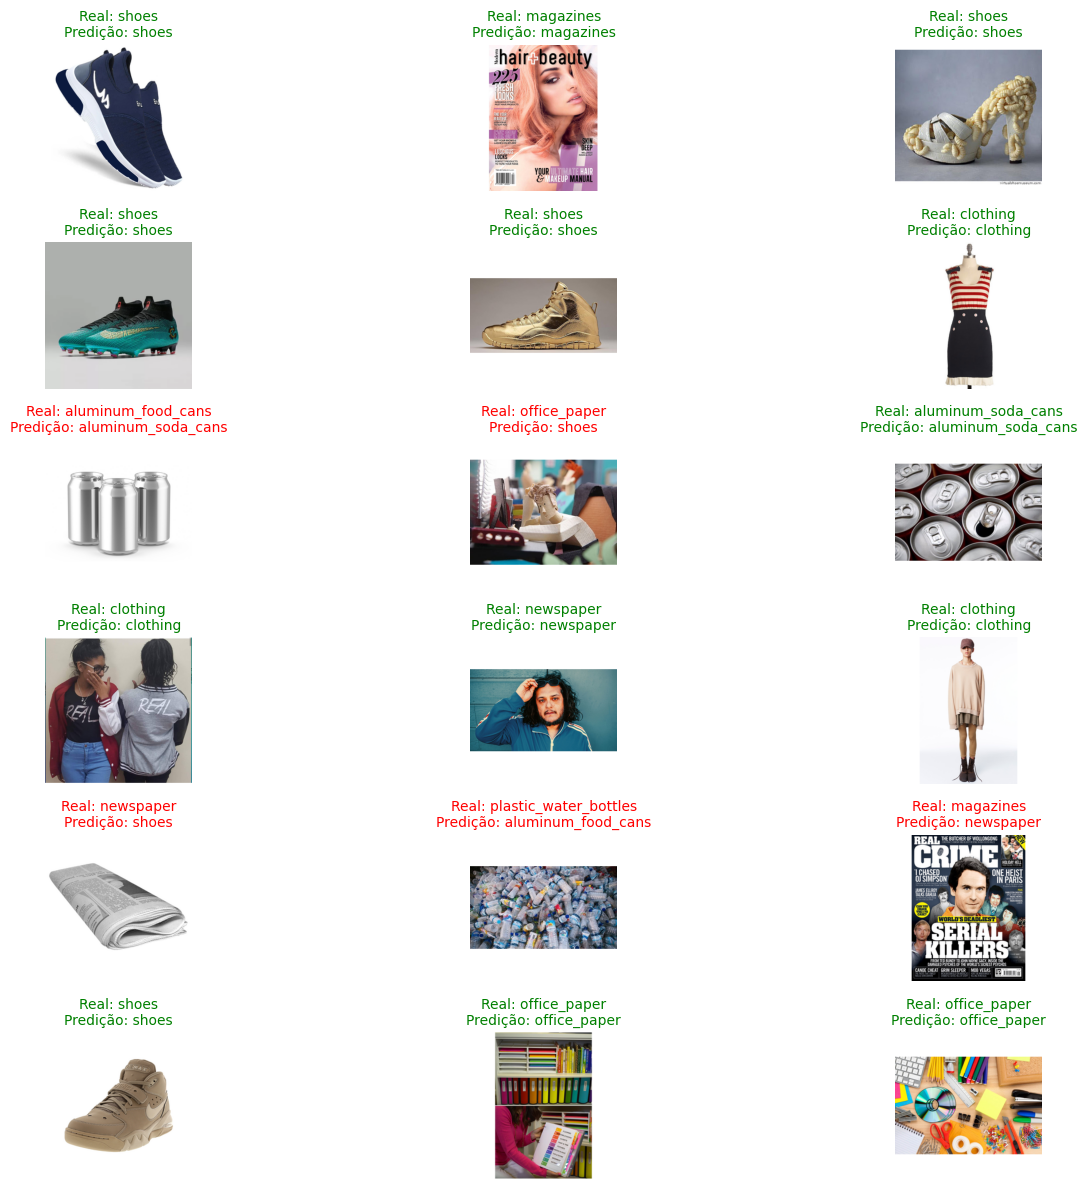

In [40]:
# ==========================================
# 6. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
# Extrair os caminhos originais do gerador de teste

filenames = test_generator.filepaths # Usando filepaths para pegar o caminho completo
indices_aleatorios = np.random.choice(range(len(filenames)), 18, replace=False)

plt.figure(figsize=(15, 12))
for i, idx in enumerate(indices_aleatorios):
    plt.subplot(6, 3, i + 1)

    # Ler imagem
    img_path = filenames[idx]
    img = mpimg.imread(img_path)

    # Textos da predição e do valor real
    true_label = class_labels[y_true[idx]]
    pred_label = class_labels[y_pred[idx]]

    # Cor: verde para acerto, vermelho para erro
    color = 'green' if true_label == pred_label else 'red'

    plt.imshow(img)
    plt.title(f"Real: {true_label}\nPredição: {pred_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()